In [ ]:
# ==============================================================================
# ANÁLISIS ESPACIAL Y TEMPORAL DE PRECIPITACIÓN (CHIRPS)
# Objetivo: Extraer series temporales, analizar quiebres (2010) y generar mapas.
# ==============================================================================

In [ ]:
import ee
from google.colab import drive
import geopandas as gpd
import geemap
import pandas as pd
import time

In [ ]:
# ------------------------------------------------------------------------------
# 1. AUTENTICACIÓN E INICIALIZACIÓN
# ------------------------------------------------------------------------------
try:
    ee.Authenticate()
    ee.Initialize(project='ee-lucasviturisantarosa')
    print("Earth Engine inicializado con éxito.")
except Exception as e:
    print(f"Error de inicialización: {e}")

drive.mount('/content/drive')

Earth Engine inicializado con éxito.
Mounted at /content/drive


In [ ]:
# ------------------------------------------------------------------------------
# 2. PROCESAMIENTO ESPACIAL DEL SHAPEFILE (Manejo de Cuencas y Subcuencas)
# ------------------------------------------------------------------------------
import zipfile
import os
import geopandas as gpd
import geemap

print("\nDescomprimiendo y cargando el Shapefile...")

# Ruta original de tu ZIP en Google Drive
ruta_zip = '/content/drive/MyDrive/GEOHIDRO_GEE_CLASES/SubCuencas_BNA.zip'
# Carpeta temporal en Colab para extraer los datos
carpeta_extraccion = '/content/temp_shapefile'

# A. Descomprimir el archivo ZIP de forma segura
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(carpeta_extraccion)

# B. Buscar automáticamente el archivo que termina en '.shp' dentro de la carpeta
ruta_shp_extraido = None
for root, dirs, files in os.walk(carpeta_extraccion):
    for file in files:
        if file.endswith('.shp'):
            ruta_shp_extraido = os.path.join(root, file)
            break # Detiene la búsqueda cuando encuentra el primer .shp

# Verificamos si realmente encontró el archivo
if ruta_shp_extraido is None:
    raise FileNotFoundError("¡No se encontró ningún archivo .shp dentro del ZIP!")

print(f"Shapefile encontrado exitosamente en: {ruta_shp_extraido}")

# C. Leer el shapefile descomprimido localmente con GeoPandas
gdf = gpd.read_file(ruta_shp_extraido)

# D. FILTRADO DIDÁCTICO:
cuenca_objetivo = '054' # Código de la Cuenca (Aconcagua)

# Filtramos primero la cuenca principal (Asegúrate que 'COD_CUEN' sea numérico en tu shp)
# Si en tu shapefile COD_CUEN es texto (string), usa cuenca_objetivo = '54'
gdf_cuenca = gdf[gdf['COD_CUEN'] == cuenca_objetivo]

# Verificación de seguridad para los estudiantes
if gdf_cuenca.empty:
    print(f"¡ADVERTENCIA! No se encontraron geometrías para la cuenca {cuenca_objetivo}. Revisa el nombre de la columna.")
else:
    print(f"Se filtraron {len(gdf_cuenca)} subcuencas para el código {cuenca_objetivo}.")

gdf_filtrado = gdf_cuenca

# E. Convertir el GeoDataFrame filtrado a un objeto de Earth Engine
aoi = geemap.geopandas_to_ee(gdf_filtrado)
geom_aoi = aoi.geometry()

print("Geometría lista para Earth Engine.")


Descomprimiendo y cargando el Shapefile...
Shapefile encontrado exitosamente en: /content/temp_shapefile/SubCuencas_BNA/SubCuencas_BNA.shp
Se filtraron 3 subcuencas para el código 054.
Geometría lista para Earth Engine.


In [ ]:
# ------------------------------------------------------------------------------
# 3. EXTRACCIÓN DE LA SERIE TEMPORAL (Procesamiento por Lotes / Batch)
# ------------------------------------------------------------------------------
# Definimos el periodo de estudio completo
ano_inicio = 1990
ano_fin = 2024
anos = range(ano_inicio, ano_fin + 1)
meses = range(1, 13)

print("\nIniciando extracción de la serie temporal (CHIRPS)...")
lista_features = []

for ano in anos:
    for mes in meses:
        # Fechas de inicio y fin para cada mes
        start_date = ee.Date.fromYMD(ano, mes, 1)
        end_date = start_date.advance(1, 'month')

        # Filtramos la colección CHIRPS para el mes específico
        chirps_mes = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").filterDate(start_date, end_date)

        # Reducción espacial (Cálculo de la lámina media en la cuenca)
        # Usamos ee.Algorithms.If para evitar errores si no hay datos en un mes
        p_media = ee.Algorithms.If(
            chirps_mes.size().gt(0),
            chirps_mes.sum().reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=geom_aoi,
                scale=5566, # Resolución nativa de CHIRPS
                maxPixels=1e9
            ).get('precipitation'),
            None
        )

        # Empaquetar los datos en una entidad (Feature) de Earth Engine
        feat = ee.Feature(None, {
            'Fecha': f"{ano}-{mes:02d}",
            'Ano': ano,
            'Mes': mes,
            'Precipitacion_mm': p_media
        })
        lista_features.append(feat)

# Descargar los datos masivamente (El "truco" de la alta velocidad)
fc_temporal = ee.FeatureCollection(lista_features)
datos_descargados = fc_temporal.getInfo()

# Transformar JSON a Pandas DataFrame
tabla_datos = []
for f in datos_descargados['features']:
    props = f['properties']
    tabla_datos.append({
        'Fecha': props.get('Fecha'),
        'Ano': props.get('Ano'),
        'Mes': props.get('Mes'),
        'P_mm': round(props.get('Precipitacion_mm'), 2) if props.get('Precipitacion_mm') else 0
    })

df_serie = pd.DataFrame(tabla_datos)

# Exportar la tabla
ruta_csv = f'/content/drive/MyDrive/GEOHIDRO_GEE_CLASES/Serie_Temporal_P_{cuenca_objetivo}.csv'
df_serie.to_csv(ruta_csv, index=False)
print(f"Tabla guardada en: {ruta_csv}")


Iniciando extracción de la serie temporal (CHIRPS)...
Tabla guardada en: /content/drive/MyDrive/GEOHIDRO_GEE_CLASES/Serie_Temporal_P_054.csv


In [ ]:
# ------------------------------------------------------------------------------
# 4. ANÁLISIS ESTADÍSTICO EN PANDAS (Interacción Python -> GEE)
# ------------------------------------------------------------------------------
print("\nRealizando análisis estadístico y detectando años extremos...")

# A. Agrupación anual (Suma de la precipitación de los 12 meses)
df_anual = df_serie.groupby('Ano')['P_mm'].sum().reset_index()

# B. Encontrar el año más seco y el más húmedo
ano_mas_seco = int(df_anual.loc[df_anual['P_mm'].idxmin(), 'Ano'])
ano_mas_humedo = int(df_anual.loc[df_anual['P_mm'].idxmax(), 'Ano'])

print(f"-> Año más SECO detectado: {ano_mas_seco} ({df_anual['P_mm'].min():.1f} mm)")
print(f"-> Año más HÚMEDO detectado: {ano_mas_humedo} ({df_anual['P_mm'].max():.1f} mm)")

# C. Análisis de reducción (Antes y Después de 2010)
media_antes_2010 = df_anual[df_anual['Ano'] <= 2010]['P_mm'].mean()
media_despues_2010 = df_anual[df_anual['Ano'] > 2010]['P_mm'].mean()
variacion_pct = ((media_despues_2010 - media_antes_2010) / media_antes_2010) * 100

print(f"\n--- Análisis de Cambio Climático / Megasequía ---")
print(f"Media Histórica (<= 2010): {media_antes_2010:.1f} mm/año")
print(f"Media Reciente (> 2010): {media_despues_2010:.1f} mm/año")
print(f"Variación Porcentual: {variacion_pct:.1f}%")


Realizando análisis estadístico y detectando años extremos...
-> Año más SECO detectado: 2021 (212.1 mm)
-> Año más HÚMEDO detectado: 2002 (674.4 mm)

--- Análisis de Cambio Climático / Megasequía ---
Media Histórica (<= 2010): 425.9 mm/año
Media Reciente (> 2010): 335.4 mm/año
Variación Porcentual: -21.3%


In [ ]:
# ------------------------------------------------------------------------------
# 5. GENERACIÓN DE MAPAS ESPACIALES EN LA NUBE (TIFFs)
# ------------------------------------------------------------------------------
print("\nGenerando mapas en Earth Engine y enviando a Google Drive...")

# Función auxiliar para exportar
def exportar_mapa(imagen, nombre_archivo):
    bounds = geom_aoi.bounds().coordinates().get(0).getInfo()
    task = ee.batch.Export.image.toDrive(
        image=imagen.clip(geom_aoi), # Recortamos la imagen final al shapefile
        description=nombre_archivo,
        folder='GEOHIDRO_GEE_CLASES',
        scale=5566,
        region=bounds,
        maxPixels=1e10
    )
    task.start()

# --- MAPA 1: Año más Seco ---
img_seco = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
             .filter(ee.Filter.calendarRange(ano_mas_seco, ano_mas_seco, 'year')) \
             .sum()
exportar_mapa(img_seco, f'CHIRPS_Ano_Mas_Seco_{ano_mas_seco}')

# --- MAPA 2: Año más Húmedo ---
img_humedo = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
               .filter(ee.Filter.calendarRange(ano_mas_humedo, ano_mas_humedo, 'year')) \
               .sum()
exportar_mapa(img_humedo, f'CHIRPS_Ano_Mas_Humedo_{ano_mas_humedo}')

# --- MAPAS 3 y 4: Estacionalidad (Ej: Invierno = Junio, Julio, Agosto) ---
# Cambia los meses aquí si deseas analizar otra estación (Ej: Verano = 12, 1, 2)
meses_estacion = [6, 7, 8] # Invierno Andino

# Función para calcular el promedio estacional en un periodo de años
def calcular_estacion_promedio(ano_start, ano_end, meses_list):
    coleccion = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
                  .filter(ee.Filter.calendarRange(ano_start, ano_end, 'year')) \
                  .filter(ee.Filter.calendarRange(meses_list[0], meses_list[-1], 'month'))
    # Sumamos todos los días de esos meses y dividimos por el número de años
    num_anos = ano_end - ano_start + 1
    return coleccion.sum().divide(num_anos)

# Mapa Estacional ANTES de 2010 (2000 - 2010)
img_estacion_antes = calcular_estacion_promedio(ano_inicio, 2010, meses_estacion)
exportar_mapa(img_estacion_antes, f'CHIRPS_Invierno_Promedio_{ano_inicio}_2010')

# Mapa Estacional DESPUÉS de 2010 (2011 - 2023)
img_estacion_despues = calcular_estacion_promedio(2011, ano_fin, meses_estacion)
exportar_mapa(img_estacion_despues, f'CHIRPS_Invierno_Promedio_2011_{ano_fin}')

print("\n¡Proceso finalizado! Revisa tu Google Drive en unos minutos para ver los archivos .tif y .csv")


Generando mapas en Earth Engine y enviando a Google Drive...

¡Proceso finalizado! Revisa tu Google Drive en unos minutos para ver los archivos .tif y .csv



[Módulo 6] Generando gráficos temporales automatizados...
- Gráfico temporal guardado en: /content/drive/MyDrive/GEOHIDRO_GEE_CLASES/Grafico_CHIRPS_054.png


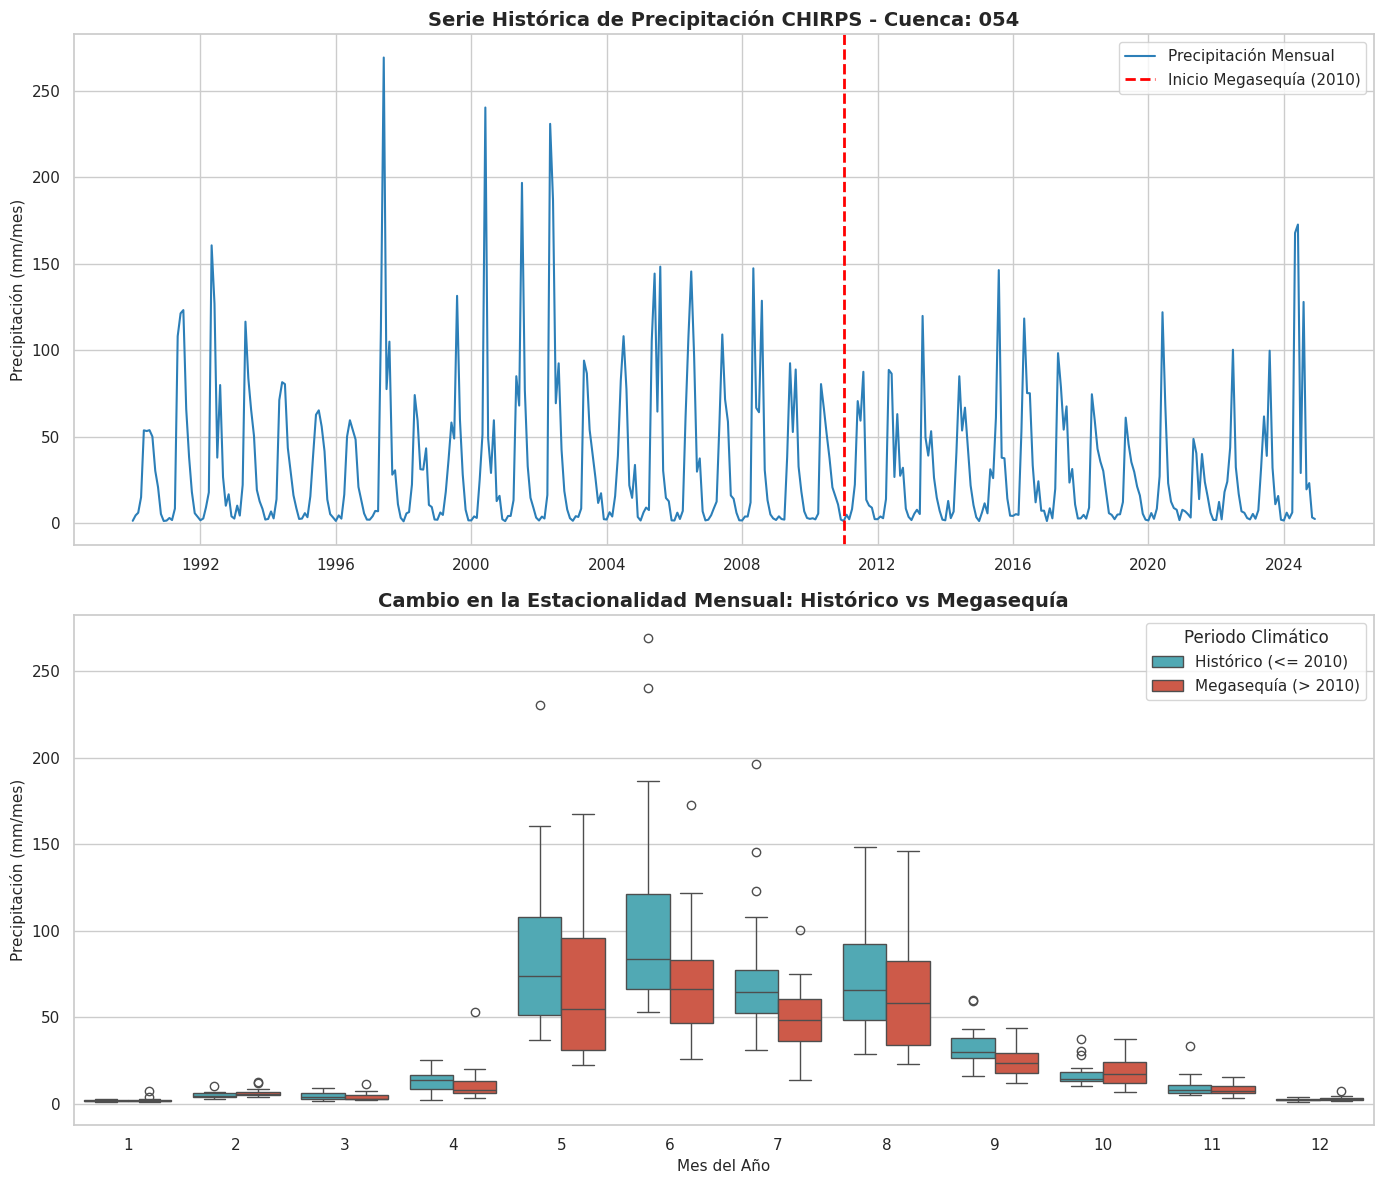

In [ ]:
# ==============================================================================
# 6. MÓDULO DE VISUALIZACIÓN TEMPORAL (Gráficos de Precipitación)
# Objetivo: Generar gráficos de la serie histórica y comparar la Megasequía.
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\n[Módulo 6] Generando gráficos temporales automatizados...")

# Configuramos el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Aseguramos que la columna Fecha sea un objeto Datetime para el eje X
df_serie['Fecha_DT'] = pd.to_datetime(df_serie['Fecha'])

# Creamos una nueva columna categórica para comparar "Antes de 2010" vs "Después"
df_serie['Periodo'] = ['Histórico (<= 2010)' if a <= 2010 else 'Megasequía (> 2010)' for a in df_serie['Ano']]

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- GRÁFICO A: Serie Histórica Completa ---
ax1 = axes[0]
ax1.plot(df_serie['Fecha_DT'], df_serie['P_mm'], color='#2c7fb8', linewidth=1.5, label='Precipitación Mensual')
# Añadir una línea vertical para marcar el inicio de la megasequía (2010)
ax1.axvline(pd.to_datetime('2010-12-31'), color='red', linestyle='--', linewidth=2, label='Inicio Megasequía (2010)')

ax1.set_title(f'Serie Histórica de Precipitación CHIRPS - Cuenca: {cuenca_objetivo}', fontsize=14, fontweight='bold')
ax1.set_ylabel('Precipitación (mm/mes)', fontsize=11)
ax1.legend(loc='upper right')

# --- GRÁFICO B: Boxplot de Estacionalidad (Antes vs Después) ---
# Un gráfico de cajas es perfecto para que los estudiantes vean la reducción de la lluvia en invierno
ax2 = axes[1]
sns.boxplot(data=df_serie, x='Mes', y='P_mm', hue='Periodo', ax=ax2, palette=['#41b6c4', '#e34a33'])

ax2.set_title('Cambio en la Estacionalidad Mensual: Histórico vs Megasequía', fontsize=14, fontweight='bold')
ax2.set_xlabel('Mes del Año', fontsize=11)
ax2.set_ylabel('Precipitación (mm/mes)', fontsize=11)
ax2.legend(title='Periodo Climático')

plt.tight_layout()

# Guardar y mostrar
ruta_grafico_p = f'/content/drive/MyDrive/GEOHIDRO_GEE_CLASES/Grafico_CHIRPS_{cuenca_objetivo}.png'
plt.savefig(ruta_grafico_p, dpi=300)
print(f"- Gráfico temporal guardado en: {ruta_grafico_p}")
plt.show()


[Módulo 7] Descargando matrices GeoTIFF para renderizado nativo en Python...
- ¡Figura cartográfica guardada con éxito en: /content/drive/MyDrive/GEOHIDRO_GEE_CLASES/Mapa_Estatico_Nativo_054.png


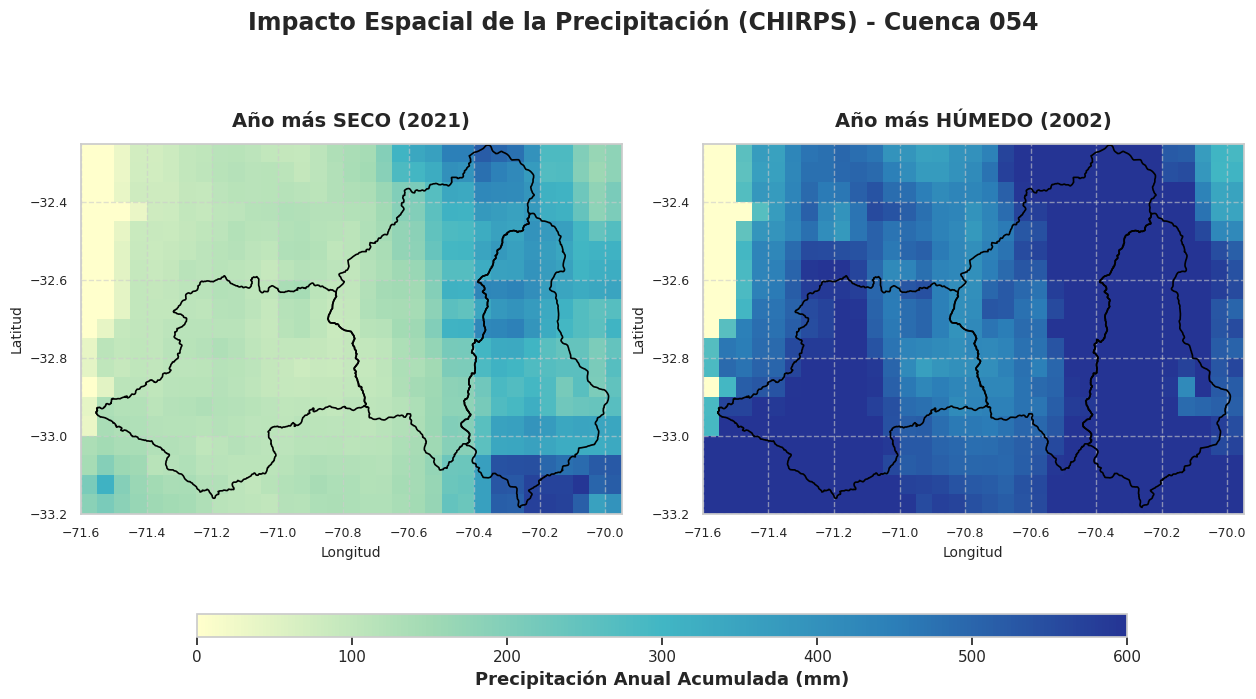

In [ ]:
# ==============================================================================
# 7. MÓDULO DE VISUALIZACIÓN ESPACIAL (Solución Nativa en Python / Rasterio)
# Objetivo: Descargar la matriz de datos real (GeoTIFF) para un ploteo perfecto.
# ==============================================================================
import requests
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print("\n[Módulo 7] Descargando matrices GeoTIFF para renderizado nativo en Python...")

# 1. Parámetros visuales
paleta_pp = ['#ffffcc', '#a1dab4', '#41b6c4', '#2c7fb8', '#253494']
region_bbox = geom_aoi.bounds()
vmin, vmax = 0, 600

# Crear el mapa de colores continuo de Matplotlib (Equivalente a scale_fill_gradientn)
cmap = mcolors.LinearSegmentedColormap.from_list('escala_chirps', paleta_pp)

def plot_mapa_nativo(ee_image, titulo, ax):
    try:
        # A. Pedir a Earth Engine los DATOS REALES en formato GeoTIFF
        url = ee_image.clip(geom_aoi).getDownloadURL({
            'scale': 5566, # Resolución nativa de CHIRPS en metros
            'region': region_bbox,
            'format': 'GEO_TIFF'
        })

        # B. Descargar el archivo temporalmente
        ruta_tif = 'temp_raster.tif'
        respuesta = requests.get(url)
        with open(ruta_tif, 'wb') as f:
            f.write(respuesta.content)

        # C. Leer el GeoTIFF con Rasterio (El estándar de Python para SIG)
        with rasterio.open(ruta_tif) as src:
            matriz = src.read(1) # Leer la banda 1 (Precipitación)

            # Enmascarar los pixeles sin datos (fuera de la cuenca) para que sean transparentes
            matriz_enmascarada = np.ma.masked_where((matriz == src.nodata) | (np.isnan(matriz)), matriz)

            # Extraer los límites geográficos reales directamente del archivo TIFF
            extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

        # D. Plotear la matriz real mapeando los datos al Colormap
        # Aquí es donde la magia ocurre: el color está 100% anclado al valor del pixel
        img = ax.imshow(matriz_enmascarada, cmap=cmap, vmin=vmin, vmax=vmax, extent=extent)

        # E. Superponer el límite vectorial
        gdf_filtrado.boundary.plot(ax=ax, color='black', linewidth=1.2)

        # F. Estética del gráfico
        ax.set_title(titulo, fontsize=14, fontweight='bold', pad=12)
        ax.set_xlabel('Longitud', fontsize=10)
        ax.set_ylabel('Latitud', fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=9)
        ax.grid(True, linestyle='--', alpha=0.6)

        return img # Retornamos el objeto imagen para anclar la barra de colores

    except Exception as e:
        print(f"Error al generar el mapa nativo: {e}")
        return None

# --- Crear la Figura Compuesta ---
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Dibujar los mapas y guardar la referencia del primero para la barra de colores
img_referencia = plot_mapa_nativo(img_seco, f'Año más SECO ({ano_mas_seco})', axes[0])
plot_mapa_nativo(img_humedo, f'Año más HÚMEDO ({ano_mas_humedo})', axes[1])

# --- Añadir la Escala de Colores (Colorbar anclada a los datos) ---
if img_referencia:
    # Ahora la barra extrae los valores directamente de la matriz ploteada
    cbar = fig.colorbar(img_referencia, ax=axes.ravel().tolist(), orientation='horizontal', shrink=0.8, pad=0.15, aspect=40)
    cbar.set_label('Precipitación Anual Acumulada (mm)', fontsize=13, fontweight='bold')
    cbar.ax.tick_params(labelsize=11)

# Título general
plt.suptitle(f'Impacto Espacial de la Precipitación (CHIRPS) - Cuenca {cuenca_objetivo}', fontsize=17, fontweight='bold')

# Control de márgenes
plt.subplots_adjust(bottom=0.35, top=0.90, wspace=0.15)

# Guardar y mostrar
ruta_mapa_estatico = f'/content/drive/MyDrive/GEOHIDRO_GEE_CLASES/Mapa_Estatico_Nativo_{cuenca_objetivo}.png'
plt.savefig(ruta_mapa_estatico, dpi=300, bbox_inches='tight')
print(f"- ¡Figura cartográfica guardada con éxito en: {ruta_mapa_estatico}")

plt.show()